<table width="100%" style="border: none; border-collapse: collapse;">
  <tr>
    <td align="center" width="55%" style="border: none;">
      <h2>Centro de Investigación en Matemáticas, A.C.</h2>
    </td>
  </tr>
</table>


<h3 align="center">Evaluación del desempeño de Redes neuronales, utilizando las el conjunto validation_set_rgb, excluyendo la categoria sin etiqueta</h3>

<h4 align="center">Autor: Sarahi Ventura Angoa</h4>

<p align="center">Maestría en Cómputo Estadístico - CIMAT Mty</p>
<p align="center"> Septiembre 2025</p>


<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">
  <h4 style="margin-top:0">Evaluación del desempeño por imagen</h4>
  <p style="margin:0 0 10px 0;">
    Este <code>notebook</code> realiza una comparacion del desempeño de los modelos entrenados con los mejores hiperparametros encontrados sobre el conjunto de 23 imágenes completamente etiquetadas de forma manual <i>validation_set_rgb</i>. 
    Para cada imagen se calculan las siguientes salidas:
  </p>
  <ul style="margin-top:0;">
    <li>Matriz de confusión por imagen (10 clases)</li>
    <li>Precisión por clase (solo clases presentes en ambas fuentes)</li>
    <li>Conteo total de errores de predicción</li>
    <li>Reporte detallado de confusiones (Caso 3)</li>
  </ul>
</div>



#
<div class="alert alert-block alert-success">
<b>Importacion de las librerias</b></div>

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
from pathlib import Path


#
<div class="alert alert-block alert-success">
<b>Diccionario de las categorías </b></div>

In [2]:
# Diccionario de las categorías 
categorias = {
    0: "Árbol",
    1: "Suelo desnudo",
    2: "Pavimento",
    3: "Cuerpo de agua",
    4: "Techo de lámina",
    5: "Techo de losa",
    6: "Arbusto",
    7: "Hierba y pasto seco",
    8: "Hierba y pasto verde",
    9: "Sombra",
    10: "Sin etiqueta"
}

Ruta donde estan los archivos *.csv*
* Caract_paralelo_ 
* Etiquetado_ 

In [3]:
# =========================================================
# RUTAS
# =========================================================
ruta_etiquetas_manuales = Path("/home/victor/Documents/prueba_modelos/etiquetadas_prueba")
ruta_predicciones_modelo = Path("/home/victor/Documents/prediccion_img_prueba_mlp")  



# =========================================================
# LISTA DE ARCHIVOS
# =========================================================

archivos_etiquetados = [
    f for f in os.listdir(ruta_etiquetas_manuales)
    if f.startswith("Etiquetado_") and f.endswith(".csv")
]

archivos_caract = [
    f for f in os.listdir(ruta_predicciones_modelo)
    if f.startswith("Caract_paralelo_") and f.endswith(".csv")
]


<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">
  <p style="margin:0 0 10px 0;">
    Se consideran únicamente los <strong>Casos 1, 2 y 3</strong> y se <strong>ignoran</strong> las categorías ausentes en ambas fuentes (Caso 4).
  </p>

  <ul style="margin-top:0;">
    <li><strong>Caso 1 (Coincidencias, TP):</strong> la clase aparece tanto en las etiquetas reales como en las predicciones (verdaderos positivos a nivel de superpíxel).</li>
    <li><strong>Caso 2 (Clases omitidas, FN):</strong> la clase está presente en las etiquetas reales pero el modelo no logra predecir bien esa clase.</li>
    <li><strong>Caso 3 (Clases inventadas, FP):</strong> la clase aparece en las predicciones pero no está en las etiquetas reales.</li>
    <li><strong>Caso 4 (Ausentes en ambas):</strong> la clase no aparece en ninguna de las dos fuentes; se <em>omite</em> del análisis.</li>
  </ul>

  <h4 style="margin:10px 0 6px 0;">Métricas</h4>
  <p style="margin:0 0 8px 0;">
    <ul>
      <li>precision</li>
      <li>Recall</li>
      <li>F1-score</li>
    </ul>
    y weighted
  </p>
</div>

<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">

  <h4 style="margin:10px 0 6px 0;">Reporte de errores (Caso 3)</h4>
  <p style="margin:0;">
    Se genera un informe detallado por imagen con las <strong>clases predichas erróneamente</strong> (no presentes en las etiquetas reales), indicando para cada una de ellas las <em>clases verdaderas</em> con las que se confundieron y el <em>número de ocurrencias</em>. Las <strong>clases ausentes en ambas fuentes</strong> (Caso 4) no se incluyen por carecer de valor informativo en la evaluación del desempeño.
  </p>
</div>



* Reporte de clases predichas erróneamente en 'image_x5_176':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Sombra: 1 veces
   Total de errores para esta clase: 1

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Hierba y pasto verde: 1 veces
   Total de errores para esta clase: 1



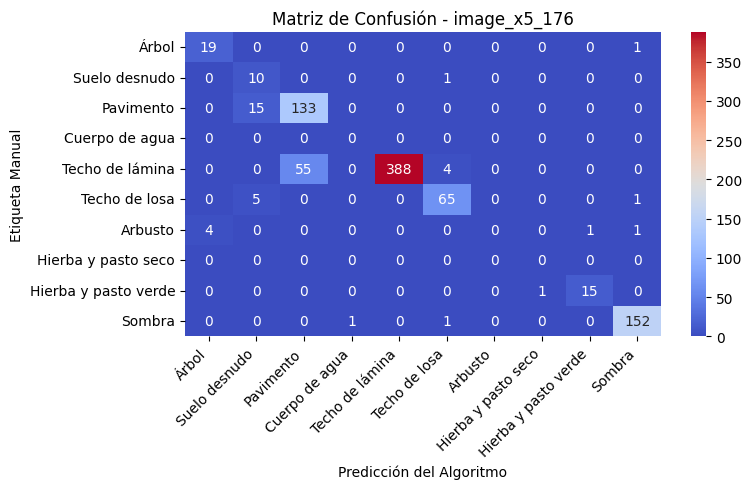


* Reporte de clases predichas erróneamente en 'image_x5_1730':
--------------------------------------------------------
'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   Total de errores para esta clase: 1

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 2 veces
   - Sombra: 3 veces
   Total de errores para esta clase: 5

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 4 veces
   - Cuerpo de agua: 1 veces
   Total de errores para esta clase: 5

Clases ausentes en ambos archivos:
 - Pavimento


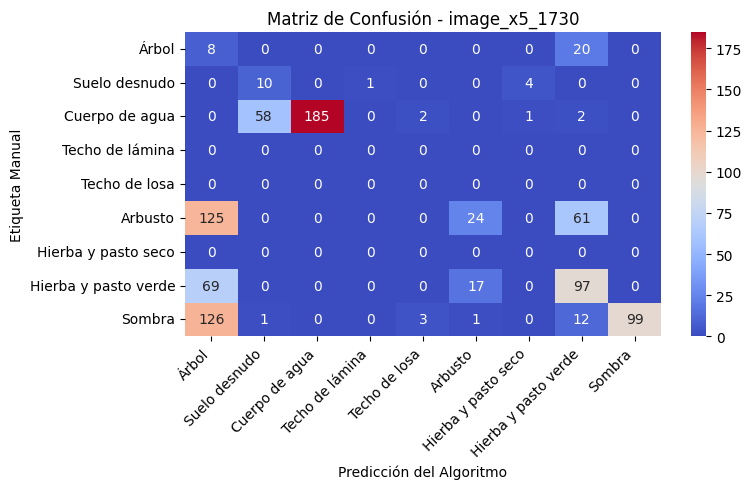


* Reporte de clases predichas erróneamente en 'image_x5_3628':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Techo de losa: 1 veces
   Total de errores para esta clase: 1

Clases ausentes en ambos archivos:
 - Cuerpo de agua


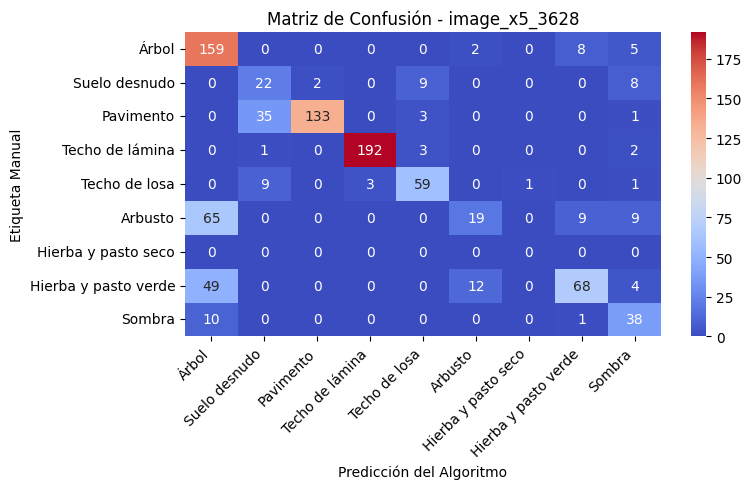


* Reporte de clases predichas erróneamente en 'image_x5_1797':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Sombra: 1 veces
   Total de errores para esta clase: 1

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 8 veces
   Total de errores para esta clase: 8



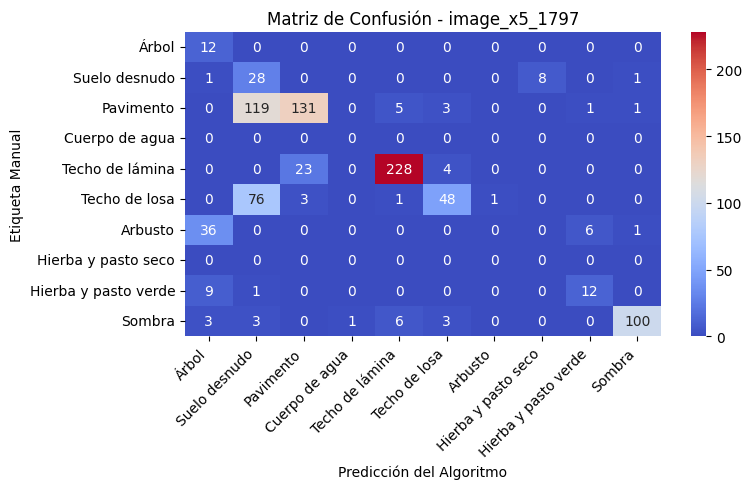


* Reporte de clases predichas erróneamente en 'image_x5_172':
--------------------------------------------------------
'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 9 veces
   - Pavimento: 3 veces
   Total de errores para esta clase: 12

Clases ausentes en ambos archivos:
 - Cuerpo de agua
 - Hierba y pasto seco


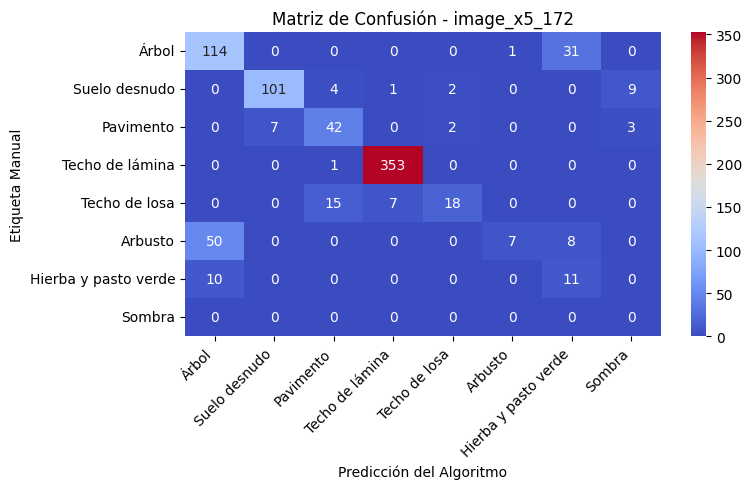


* Reporte de clases predichas erróneamente en 'image_x5_221':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 10 veces
   Total de errores para esta clase: 10

Clases ausentes en ambos archivos:
 - Cuerpo de agua


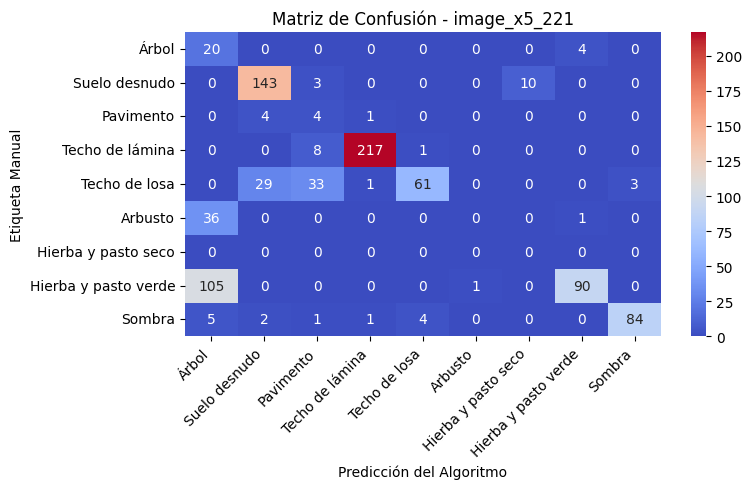


* Reporte de clases predichas erróneamente en 'image_x5_3913':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 2 veces
   Total de errores para esta clase: 2

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 2 veces
   Total de errores para esta clase: 2

Clases ausentes en ambos archivos:
 - Techo de lámina


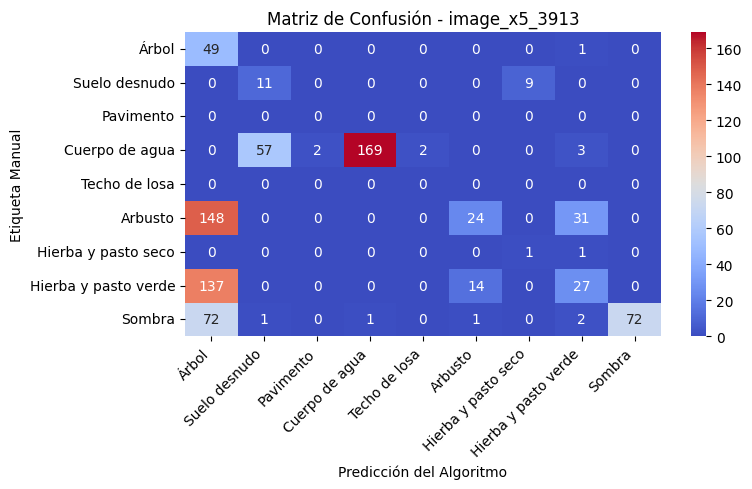


* Reporte de clases predichas erróneamente en 'image_x5_174':
--------------------------------------------------------
'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Techo de lámina: 7 veces
   Total de errores para esta clase: 7

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 6 veces
   - Suelo desnudo: 6 veces
   - Hierba y pasto verde: 4 veces
   Total de errores para esta clase: 16

Clases ausentes en ambos archivos:
 - Pavimento
 - Cuerpo de agua
 - Hierba y pasto seco


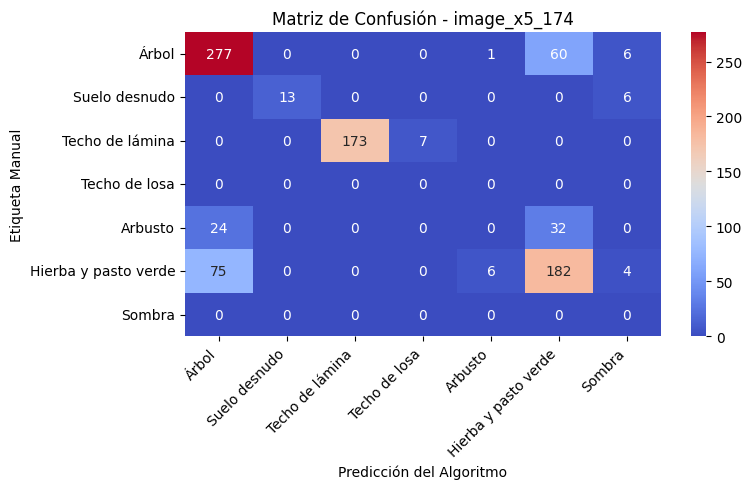


* Reporte de clases predichas erróneamente en 'image_x5_164':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 16 veces
   - Arbusto: 8 veces
   Total de errores para esta clase: 24

Clases ausentes en ambos archivos:
 - Cuerpo de agua


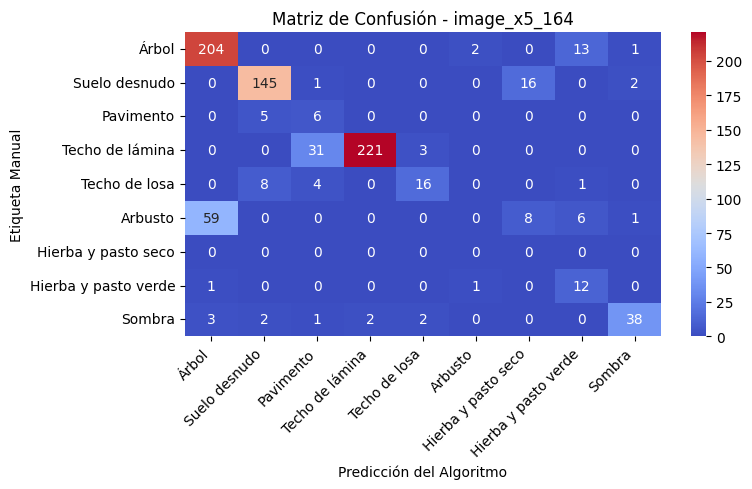


* Reporte de clases predichas erróneamente en 'image_x5_201':
--------------------------------------------------------
'Árbol' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Arbusto: 26 veces
   - Hierba y pasto verde: 5 veces
   Total de errores para esta clase: 31

'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 105 veces
   - Sombra: 12 veces
   Total de errores para esta clase: 117

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Techo de lámina: 3 veces
   - Arbusto: 2 veces
   Total de errores para esta clase: 5

Clases ausentes en ambos archivos:
 - Cuerpo de agua


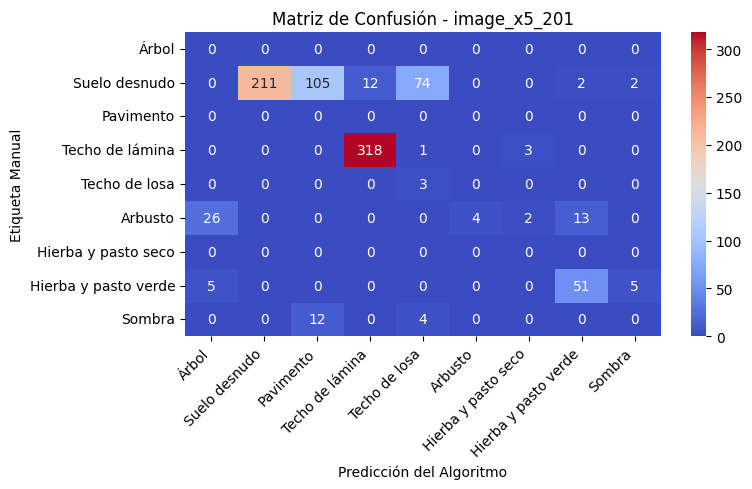


* Reporte de clases predichas erróneamente en 'image_x5_2471':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 3 veces
   Total de errores para esta clase: 3

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 3 veces
   - Suelo desnudo: 5 veces
   - Arbusto: 4 veces
   - Hierba y pasto verde: 6 veces
   Total de errores para esta clase: 18

Clases ausentes en ambos archivos:
 - Cuerpo de agua


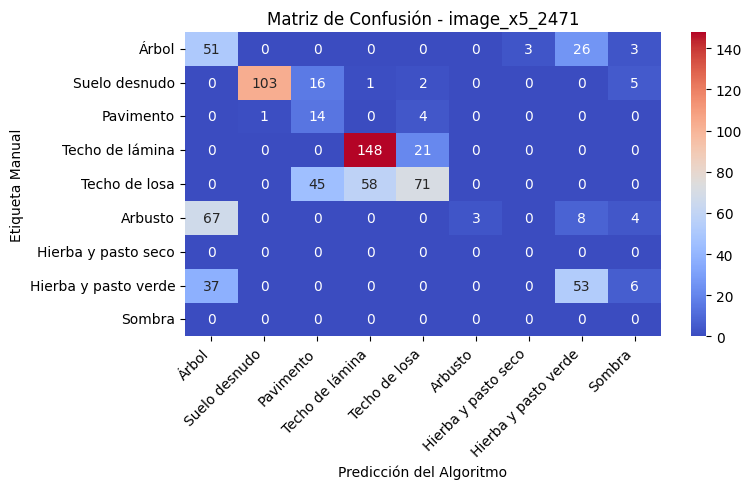


* Reporte de clases predichas erróneamente en 'image_x5_2486':
--------------------------------------------------------
Clases ausentes en ambos archivos:
 - Cuerpo de agua
 - Hierba y pasto seco


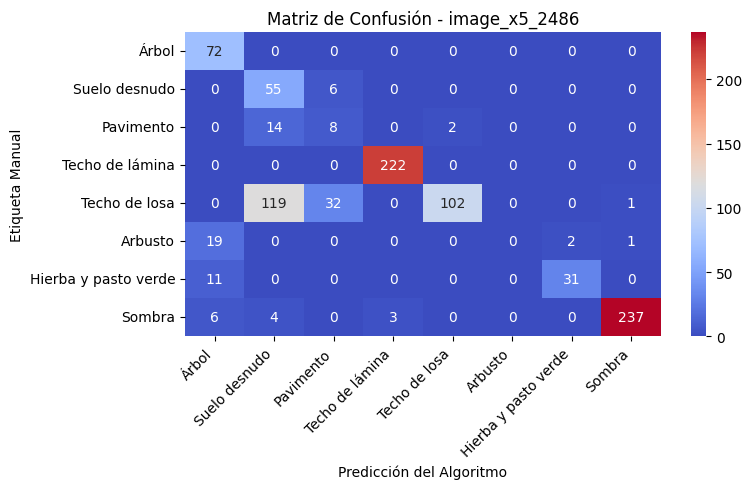


* Reporte de clases predichas erróneamente en 'image_x5_3378':
--------------------------------------------------------
Clases ausentes en ambos archivos:
 - Cuerpo de agua


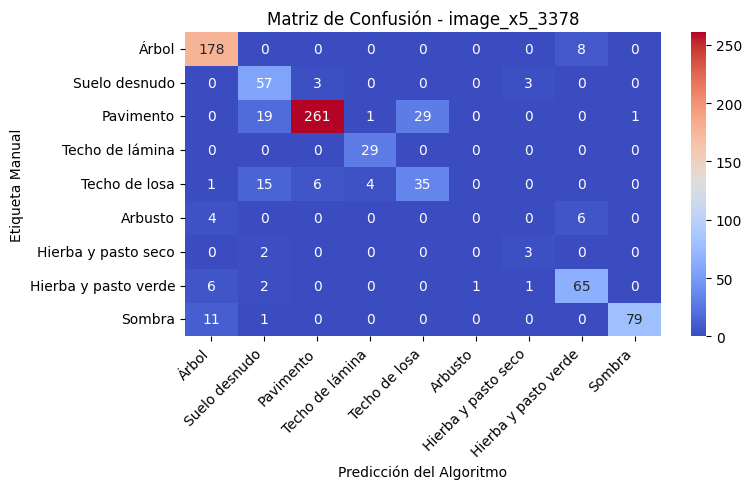


* Reporte de clases predichas erróneamente en 'image_x5_2983':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 19 veces
   Total de errores para esta clase: 19

Clases ausentes en ambos archivos:
 - Cuerpo de agua


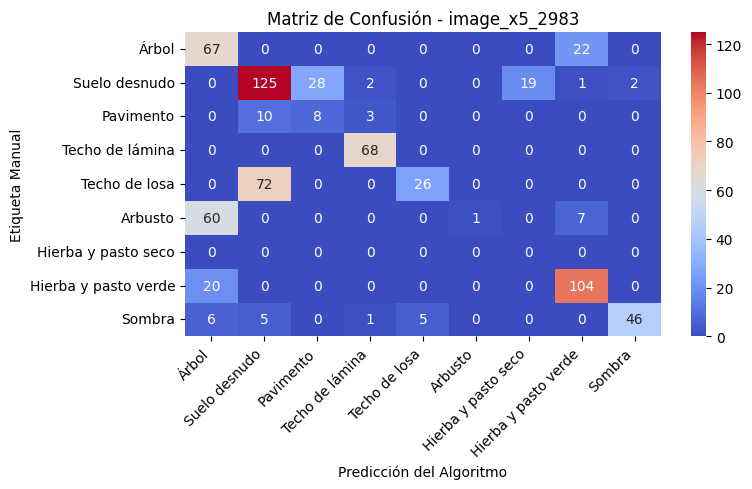


* Reporte de clases predichas erróneamente en 'image_x5_2868':
--------------------------------------------------------
'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Pavimento: 1 veces
   Total de errores para esta clase: 1

Clases ausentes en ambos archivos:
 - Cuerpo de agua
 - Hierba y pasto seco


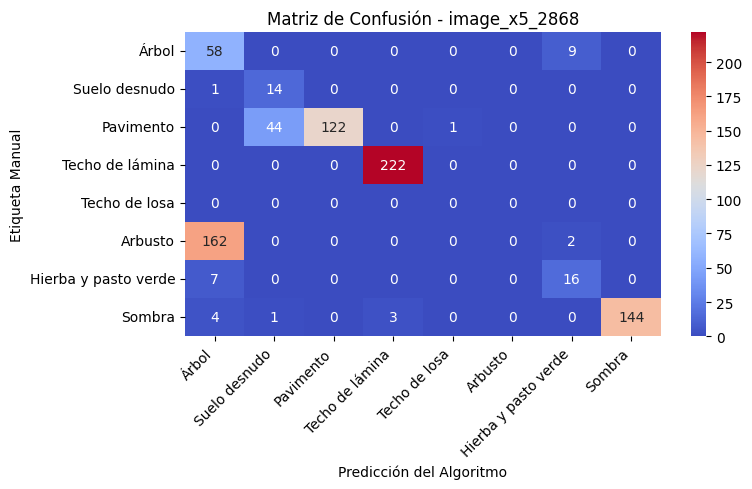


* Reporte de clases predichas erróneamente en 'image_x5_163':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 9 veces
   - Techo de losa: 17 veces
   Total de errores para esta clase: 26

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 17 veces
   - Suelo desnudo: 3 veces
   - Techo de losa: 18 veces
   - Arbusto: 1 veces
   - Hierba y pasto verde: 11 veces
   Total de errores para esta clase: 50

Clases ausentes en ambos archivos:
 - Cuerpo de agua
 - Hierba y pasto seco


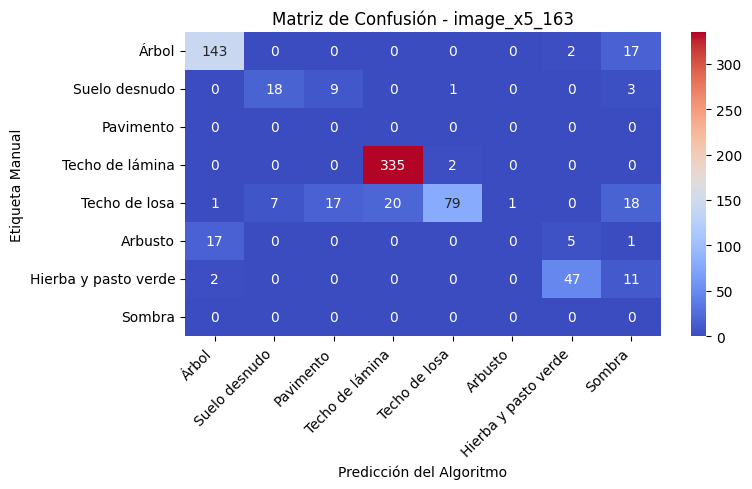


* Reporte de clases predichas erróneamente en 'image_x5_3425':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 6 veces
   - Hierba y pasto verde: 10 veces
   Total de errores para esta clase: 16

Clases ausentes en ambos archivos:
 - Cuerpo de agua


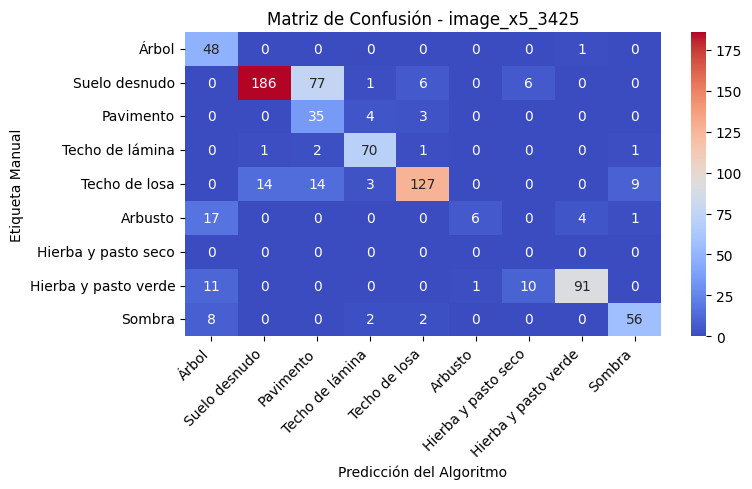


* Reporte de clases predichas erróneamente en 'image_x5_2502':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 31 veces
   - Cuerpo de agua: 12 veces
   Total de errores para esta clase: 43

'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 1 veces
   Total de errores para esta clase: 1

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   - Cuerpo de agua: 16 veces
   Total de errores para esta clase: 17

Clases ausentes en ambos archivos:
 - Hierba y pasto seco


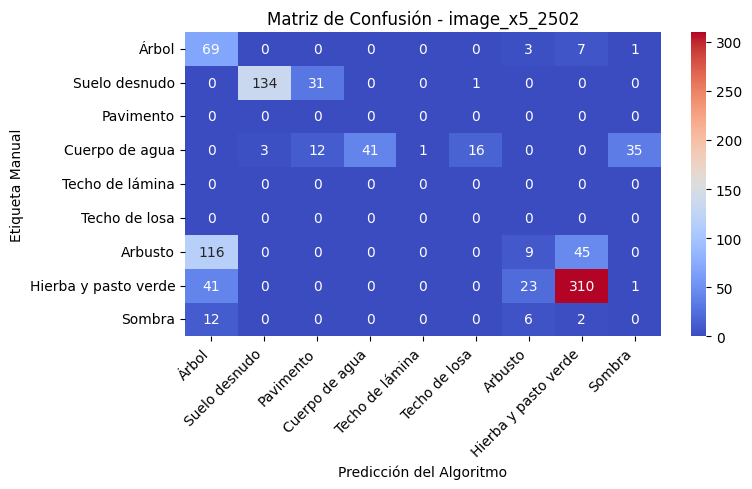


* Reporte de clases predichas erróneamente en 'image_x5_1272':
--------------------------------------------------------
'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 4 veces
   - Suelo desnudo: 9 veces
   - Pavimento: 12 veces
   - Arbusto: 3 veces
   - Hierba y pasto verde: 7 veces
   Total de errores para esta clase: 35

Clases ausentes en ambos archivos:
 - Cuerpo de agua
 - Hierba y pasto seco


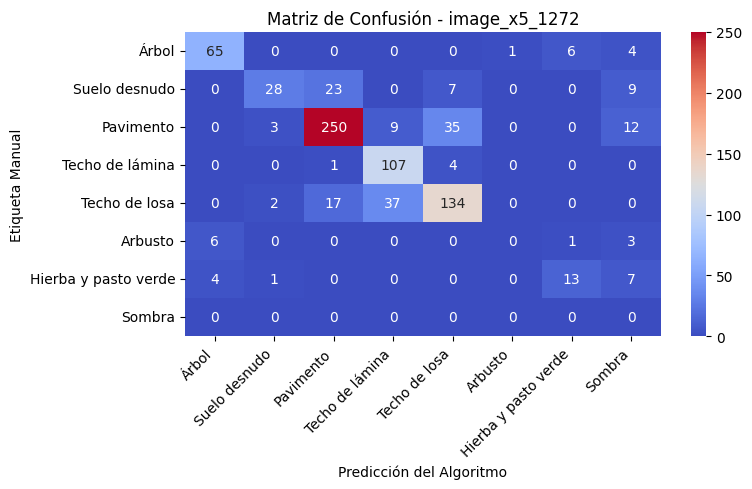


* Reporte de clases predichas erróneamente en 'image_x5_2448':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 31 veces
   Total de errores para esta clase: 31

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   Total de errores para esta clase: 1

Clases ausentes en ambos archivos:
 - Cuerpo de agua
 - Techo de lámina


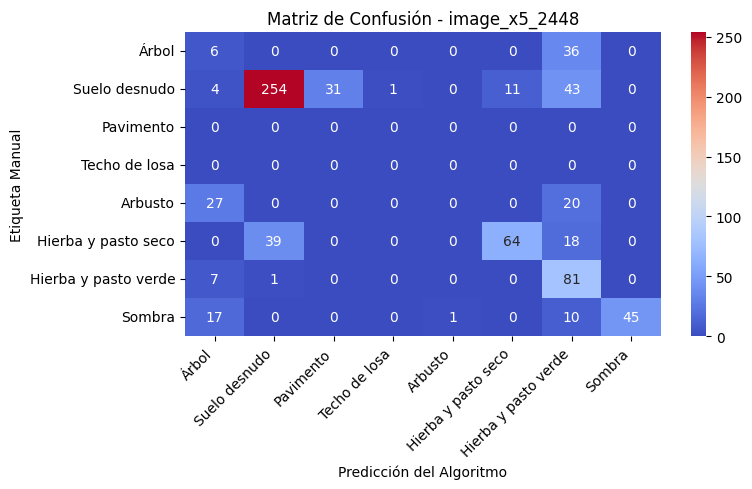


* Reporte de clases predichas erróneamente en 'image_x5_250':
--------------------------------------------------------
'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Pavimento: 8 veces
   - Techo de lámina: 3 veces
   - Sombra: 8 veces
   Total de errores para esta clase: 19

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 9 veces
   Total de errores para esta clase: 9

Clases ausentes en ambos archivos:
 - Cuerpo de agua


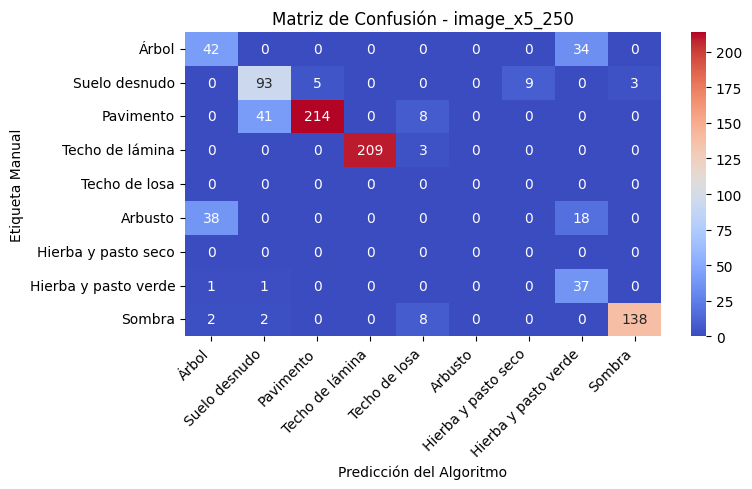


* Reporte de clases predichas erróneamente en 'image_x5_181':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 9 veces
   Total de errores para esta clase: 9

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   Total de errores para esta clase: 1

'Arbusto' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 3 veces
   Total de errores para esta clase: 3

Clases ausentes en ambos archivos:
 - Cuerpo de agua
 - Techo de lámina


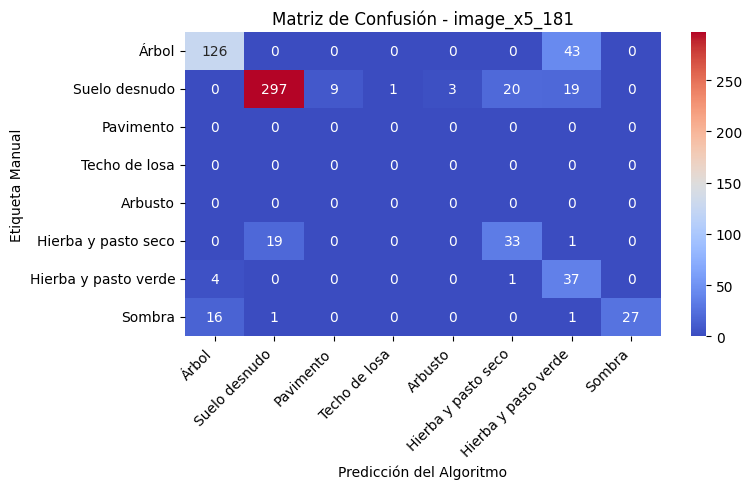


* Reporte de clases predichas erróneamente en 'image_x5_4037':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Hierba y pasto verde: 2 veces
   Total de errores para esta clase: 2



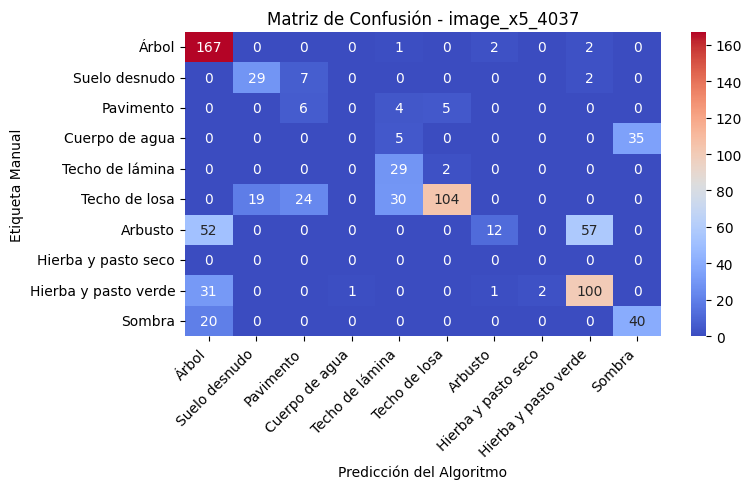

In [ ]:
# =========================================================
# Listas para almacenar resultados de precisión y errores por imagen
# =========================================================
resultados_precision = []          # precisión general y por categoría
resumen_errores_imagen = []        # errores totales y clases ausentes por imagen


# =========================================================
# Lista para almacenar TP, FP, FN, TN y soporte por imagen y por clase
# =========================================================
resultados_detalle_confusion = []
metricas_globales_img= []
# =========================================================
# Procesar cada imagen (archivo Caract_paralelo_*)
# =========================================================
for archivo_caract in archivos_caract:

    # nombre base de imagen
    nombre_imagen = archivo_caract.replace("Caract_paralelo_", "").replace(".csv", "")
    archivo_etiquetado = f"Etiquetado_{nombre_imagen}.csv"

    # Verificar si existe el archivo de etiquetado manual
    path_etiquetado = ruta_etiquetas_manuales / archivo_etiquetado
    if not path_etiquetado.exists():
        print(f"No se encontró el archivo etiquetado para {nombre_imagen}. Saltando...")
        continue

    # -------------------------
    # Cargar predicción y manual
    # -------------------------
    path_caract = ruta_predicciones_modelo / archivo_caract

    df_caract = pd.read_csv(path_caract, usecols=["indice", "prediction"])
    df_etiquetado = pd.read_csv(path_etiquetado, usecols=["indice", "categoria"])

    df_caract["indice"] = df_caract["indice"].astype(int)
    df_etiquetado["indice"] = df_etiquetado["indice"].astype(int)

    # -------------------------
    # Emparejar por índice
    # -------------------------
    df_comparacion = df_etiquetado.merge(df_caract, on="indice", how="left")
    df_comparacion.rename(columns={
        "categoria": "Etiqueta_Manual",
        "prediction": "Prediccion_Algoritmo"
    }, inplace=True)

    # Eliminar superpíxeles "Sin etiqueta" (clase 10)
    df_comparacion = df_comparacion[df_comparacion["Etiqueta_Manual"] != 10]

    if df_comparacion.empty:
        print(f"La imagen {nombre_imagen} no tiene clases distintas de 10. Saltando...")
        continue
    

    # ==========================
    # Definir clases presentes 
    # ==========================
    clases_etiquetadas = set(df_comparacion["Etiqueta_Manual"].unique())
    clases_predichas  = set(df_comparacion["Prediccion_Algoritmo"].unique())
    
    # Identificar clases ausentes en ambos archivos
    clases_no_aparecen = []
    clases_a_graficar = []

    clases_a_graficar = []
    for c in categorias.keys():
        if c == 10:
            continue
        esta_en_etiquetas     = c in clases_etiquetadas
        esta_en_predicciones  = c in clases_predichas

        if not esta_en_etiquetas and not esta_en_predicciones:
            clases_no_aparecen.append(categorias[c])
        else:
            clases_a_graficar.append(c)


    # ==========================
    # Matriz de confusión para esta imagen NUEVO
    # ==========================
    y_true = df_comparacion["Etiqueta_Manual"].values
    y_pred = df_comparacion["Prediccion_Algoritmo"].values

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=clases_a_graficar
    )
    etiquetas_mapeadas = [categorias[c] for c in clases_a_graficar]

    # cm es una matriz KxK donde:
    # filas    = clases reales     (Etiqueta_Manual)
    # columnas = clases predichas  (Prediccion_Algoritmo)

    total_pixeles = cm.sum()  # total de superpíxeles considerados en esta imagen

    # ==========================
    # Calcular TP, FP, FN, TN y soporte por clase
    # ==========================
    sum_support = sum_p_weighted = sum_r_weighted = sum_f1_weighted = sum_support_f1= 0.0

    for idx, clase in enumerate(clases_a_graficar):
        nombre_clase = categorias[clase]
                
        # ACTUAL POR CHAT:
        
        tp = cm[idx, idx]           # diagonal
        fp = cm[:, idx].sum() - tp  # columna clase - tp
        fn = cm[idx, :].sum() - tp  # fila clase - tp
        tn = total_pixeles - tp - fp - fn     # todo lo demás
        
        support = tp + fn   # nº de ejemplos reales de esta clase

        if support > 0:
            # Hay ejemplos reales de la clase (caso 1 o 2)

            # --- Precision ---
            if tp > 0:
                precision = tp / (tp + fp)
                recall= tp / (tp + fn)
                f1_score = 2 * ( (precision * recall)/ (precision +recall))
            else:
                # Caso 2: hay etiquetas reales, pero nunca se predijo la clase, es decir TP=0
                precision = 0.0
                recall = 0.0
                f1_score = np.nan
            

            # Acumular para weighted (solo clases con soporte>0)
            # Para P y R sí usamos siempre support
            sum_support += support
            sum_p_weighted += support * precision
            sum_r_weighted += support * recall

            # Acumular para weighted F1 SOLO si F1 está definida
            if not np.isnan(f1_score):
                sum_f1_weighted += support * f1_score
                sum_support_f1  += support

        else:
            # support == 0,   casos 3 
            if (tp + fp) > 0:
                # CASO 3: No en etiquetas, Sí en predicción
                precision = 0.0
                recall = np.nan
                f1_score= np.nan
            else:
                # CASO 4: No en etiquetas, No en predicción
                precision = np.nan
                recall = np.nan
                f1_score = np.nan
            # No se acumula nada en los weighted
    
        soporte = cm[idx, :].sum()            # = tp + fn = nº reales de esa clase

        resultados_detalle_confusion.append({
            "Imagen": nombre_imagen,
            "Clase_ID": clase,
            "Clase_nombre": nombre_clase,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "support": int(soporte),
            "Pre.": precision,
            "Rec.": recall, 
            "F1": f1_score,
            "total_pixeles_imagen": int(total_pixeles)
        })
        
    # ==========================
    # Reporte de errores (Caso 3)
    # ==========================
    errores_predicciones = []

    print(f"\n* Reporte de clases predichas erróneamente en '{nombre_imagen}':")
    print("--------------------------------------------------------")

    for clase_predicha in categorias.keys():
        if clase_predicha == 10:
            continue

        nombre_clase = categorias[clase_predicha]

        fue_predicha = (df_comparacion["Prediccion_Algoritmo"] == clase_predicha).any()
        existe_en_verdaderas = (df_comparacion["Etiqueta_Manual"] == clase_predicha).any()

        if fue_predicha and not existe_en_verdaderas:
            errores_df = df_comparacion[df_comparacion["Prediccion_Algoritmo"] == clase_predicha]
            conteo_confusiones = errores_df["Etiqueta_Manual"].value_counts().sort_index()

            print(f"'{nombre_clase}' fue predicha pero nunca estuvo en etiquetas reales.")
            print("   Se confundió con:")
            for clase_real, conteo in conteo_confusiones.items():
                nombre_real = categorias.get(int(clase_real), "Desconocida")
                print(f"   - {nombre_real}: {conteo} veces")
            print(f"   Total de errores para esta clase: {len(errores_df)}\n")

            errores_predicciones.append({
                "Clase_predicha": nombre_clase,
                "ID": clase_predicha,
                "Total_errores": len(errores_df),
                "Confusiones": dict(conteo_confusiones.map(int))
            })

    # Caso 4: ausentes en ambos
    if clases_no_aparecen:
        print("Clases ausentes en ambos archivos:")
        for clase_nombre in clases_no_aparecen:
            print(f" - {clase_nombre}")

    total_errores_imagen = sum(e["Total_errores"] for e in errores_predicciones)
    resumen_errores_imagen.append({
        "Imagen": nombre_imagen,
        "Errores_totales_predichos_erróneamente": total_errores_imagen,
        "Clases_ausentes": clases_no_aparecen
    })

    # ==========================
    # Graficar matriz de confusión
    # ==========================
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="coolwarm",
        xticklabels=etiquetas_mapeadas,
        yticklabels=etiquetas_mapeadas
    )
    plt.xlabel("Predicción del Algoritmo")
    plt.ylabel("Etiqueta Manual")
    plt.title(f"Matriz de Confusión - {nombre_imagen}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
        
        
    # ---- Métricas globales weighted por imagen ----
    if sum_support > 0:
        weighted_p = (sum_p_weighted / sum_support) * 100
        weighted_r = (sum_r_weighted / sum_support) * 100
    else:
        weighted_p = np.nan
        weighted_r = np.nan

    if sum_support_f1 > 0:
        weighted_f1 = (sum_f1_weighted / sum_support_f1) * 100
    else:
        weighted_f1 = np.nan

    metricas_globales_img.append({
        "Imagen": nombre_imagen,
        "Pre_w": weighted_p,
        "Rec_w": weighted_r,
        "F1_w": weighted_f1
    })
    

# =========================================================
# DataFrame final con TP, FP, FN, TN, soporte por imagen y clase, precision, recall, f1-score
# =========================================================
df_detalle_confusion = pd.DataFrame(resultados_detalle_confusion)
df_metricas_globales_img = pd.DataFrame(metricas_globales_img)
df_errores = pd.DataFrame(resumen_errores_imagen)


In [5]:
print(df_detalle_confusion.to_string())

            Imagen  Clase_ID          Clase_nombre   TP   FP   FN   TN  support      Pre.      Rec.        F1  total_pixeles_imagen
0     image_x5_176         0                 Árbol   19    4    1  849       20  0.826087  0.950000  0.883721                   873
1     image_x5_176         1         Suelo desnudo   10   20    1  842       11  0.333333  0.909091  0.487805                   873
2     image_x5_176         2             Pavimento  133   55   15  670      148  0.707447  0.898649  0.791667                   873
3     image_x5_176         3        Cuerpo de agua    0    1    0  872        0  0.000000       NaN       NaN                   873
4     image_x5_176         4       Techo de lámina  388    0   59  426      447  1.000000  0.868009  0.929341                   873
5     image_x5_176         5         Techo de losa   65    6    6  796       71  0.915493  0.915493  0.915493                   873
6     image_x5_176         6               Arbusto    0    0    6  867      

#
<div class="alert alert-block alert-success">
<b>Dataframe del resumen de errores por clase no presente en etiquetas (caso 3) y clases ausentes en ambos
archivos (caso 4)</b></div>

In [6]:
df_errores

,Imagen,Errores_totales_predichos_erróneamente,Clases_ausentes
0,image_x5_176,2,[]
1,image_x5_1730,11,[Pavimento]
2,image_x5_3628,1,[Cuerpo de agua]
3,image_x5_1797,9,[]
4,image_x5_172,12,"[Cuerpo de agua, Hierba y pasto seco]"
5,image_x5_221,10,[Cuerpo de agua]
6,image_x5_3913,4,[Techo de lámina]
7,image_x5_174,23,"[Pavimento, Cuerpo de agua, Hierba y pasto seco]"
8,image_x5_164,24,[Cuerpo de agua]
9,image_x5_201,153,[Cuerpo de agua]



#
<div class="alert alert-block alert-success">
<b>Metricas globales y por categoría, para cada una de las imagenes de prueba</b></div>

In [7]:
# Convertir precisiones por clase a porcentaje
df_detalle_confusion["Pre_w"] = df_detalle_confusion["Pre."] * 100.0


# TABLA DE PRECISION
tabla_prec = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="Pre_w")
        .rename(columns=categorias)
)

# Pre_w ya está en porcentaje, así que la dejas igual
tabla_prec = (
    df_metricas_globales_img
        .set_index("Imagen")[["Pre_w"]]
        .join(tabla_prec, how="left")
)
tabla_prec

,Pre_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra
Imagen,,,,,,,,,,,
image_x5_176,91.971350,82.608696,33.333333,70.744681,0.000000,100.000000,91.549296,0.000000,0.000000,93.750000,98.064516
image_x5_1730,76.167383,2.439024,14.492754,NaN,100.000000,0.000000,0.000000,57.142857,0.000000,50.520833,100.000000
image_x5_3628,76.974864,56.183746,32.835821,98.518519,NaN,98.461538,79.729730,57.575758,0.000000,79.069767,55.882353
image_x5_1797,79.944603,19.672131,12.334802,83.439490,0.000000,95.000000,82.758621,0.000000,0.000000,63.157895,97.087379
image_x5_172,85.574640,65.517241,93.518519,67.741935,NaN,97.783934,81.818182,87.500000,NaN,22.000000,0.000000
image_x5_221,85.847300,12.048193,80.337079,8.163265,NaN,98.636364,92.424242,0.000000,0.000000,94.736842,96.551724
image_x5_3913,70.528603,12.068966,15.942029,0.000000,99.411765,NaN,0.000000,61.538462,10.000000,41.538462,100.000000
image_x5_174,72.722390,73.670213,100.000000,NaN,NaN,100.000000,0.000000,0.000000,NaN,66.423358,0.000000
image_x5_164,78.740685,76.404494,90.625000,13.953488,NaN,99.103139,76.190476,0.000000,0.000000,37.500000,90.476190


In [ ]:
# TABLA DE RECALL
df_detalle_confusion["Rec_w"] = df_detalle_confusion["Rec."] * 100.0


tabla_recall = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="Rec_w")
        .rename(columns=categorias)
)

tabla_recall = (
    df_metricas_globales_img
        .set_index("Imagen")[["Rec_w"]]
        .join(tabla_recall, how="left")
)
tabla_recall


,Rec_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra
Imagen,,,,,,,,,,,
image_x5_176,89.576174,95.000000,90.909091,89.864865,NaN,86.800895,91.549296,0.000000,NaN,93.750000,98.701299
image_x5_1730,45.680346,28.571429,66.666667,NaN,74.596774,NaN,NaN,11.428571,NaN,53.005464,40.909091
image_x5_3628,73.248408,91.379310,53.658537,77.325581,NaN,96.969697,80.821918,18.627451,NaN,51.127820,77.551020
image_x5_1797,63.885714,100.000000,73.684211,50.384615,NaN,89.411765,37.209302,0.000000,NaN,54.545455,86.206897
image_x5_172,81.053952,78.082192,86.324786,77.777778,NaN,99.717514,45.000000,10.769231,NaN,52.380952,NaN
image_x5_221,70.986239,83.333333,91.666667,44.444444,NaN,96.017699,48.031496,0.000000,NaN,45.918367,86.597938
image_x5_3913,42.275449,98.000000,55.000000,NaN,72.532189,NaN,NaN,11.822660,50.000000,15.168539,48.322148
image_x5_174,74.480370,80.523256,68.421053,NaN,NaN,96.111111,NaN,0.000000,NaN,68.164794,NaN
image_x5_164,78.773006,92.727273,88.414634,54.545455,NaN,86.666667,55.172414,0.000000,NaN,85.714286,79.166667


In [9]:
# TABLA DE F1-SCORE
df_detalle_confusion["F1_w"] = df_detalle_confusion["F1"] * 100.0

# 2) Tabla ancha por imagen x clase, usando F1_pct
tabla_f1 = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="F1_w")
        .rename(columns=categorias)
)

# 3) Añadir F1_w (weighted por imagen) a la izquierda
tabla_f1 = (
    df_metricas_globales_img
        .set_index("Imagen")[["F1_w"]]   # ya está en porcentaje
        .join(tabla_f1, how="left")
)

tabla_f1

,F1_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra
Imagen,,,,,,,,,,,
image_x5_176,90.787843,88.372093,48.780488,79.166667,NaN,92.934132,91.549296,NaN,NaN,93.750000,98.381877
image_x5_1730,53.124713,4.494382,23.809524,NaN,85.450346,NaN,NaN,19.047619,NaN,51.733333,58.064516
image_x5_3628,72.399965,69.584245,40.740741,86.644951,NaN,97.709924,80.272109,28.148148,NaN,62.100457,64.957265
image_x5_1797,71.548139,32.876712,21.132075,62.829736,NaN,92.121212,51.336898,NaN,NaN,58.536585,91.324201
image_x5_172,80.289976,71.250000,89.777778,72.413793,NaN,98.741259,58.064516,19.178082,NaN,30.985915,NaN
image_x5_221,77.829492,21.052632,85.628743,13.793103,NaN,97.309417,63.212435,NaN,NaN,61.855670,91.304348
image_x5_3913,46.508756,21.491228,24.719101,NaN,83.870968,NaN,NaN,19.834711,16.666667,22.222222,65.158371
image_x5_174,78.543467,76.944444,81.250000,NaN,NaN,98.016997,NaN,NaN,NaN,67.282810,NaN
image_x5_164,85.794783,83.778234,89.506173,22.222222,NaN,92.468619,64.000000,NaN,NaN,52.173913,84.444444


In [11]:
import numpy as np
import pandas as pd

# ------------ 1) Filtrar solo las tres imágenes de interés ------------
imgs_interes = ["image_x5_1730", "image_x5_1272", "image_x5_250"]

df_sel = df_detalle_confusion[df_detalle_confusion["Imagen"].isin(imgs_interes)].copy()

# ------------ 2) Agrupar por categoría y sumar TP, FP, FN, support ------------
# Usa "Clase_nombre" o "Clase_ID", según prefieras agrupar
grouped = (
    df_sel
    .groupby("Clase_nombre", as_index=True)
    .agg({
        "TP": "sum",
        "FP": "sum",
        "FN": "sum",
        "support": "sum"
    })
)

# ------------ 3) Recalcular precisión, recall y F1 por categoría ------------
# Evitar divisiones entre cero
tp = grouped["TP"].astype(float)
fp = grouped["FP"].astype(float)
fn = grouped["FN"].astype(float)
support = grouped["support"].astype(float)

precision = np.where(tp + fp > 0, tp / (tp + fp), np.nan)
recall    = np.where(tp + fn > 0, tp / (tp + fn), np.nan)
f1        = np.where(
    (precision + recall) > 0,
    2 * precision * recall / (precision + recall),
    np.nan
)

# Guardar en un DataFrame final (en proporciones 0–1)
df_metrics_clase = pd.DataFrame({
    "TP": tp,
    "FP": fp,
    "FN": fn,
    "support": support,
    "precision": precision,
    "recall": recall,
    "f1": f1,
})

# Si quieres en porcentaje (como el resto de tus tablas):
df_metrics_clase_pct = df_metrics_clase.copy()
df_metrics_clase_pct[["precision", "recall", "f1"]] *= 100

print("\nMÉTRICAS POR CATEGORÍA (3 imágenes juntas, en %):\n")
print(df_metrics_clase_pct[["precision", "recall", "f1", "support"]])


# ------------ 4) Métricas globales weighted ------------
total_support = support.sum()

precision_w = np.nansum(precision * support) / total_support
recall_w    = np.nansum(recall    * support) / total_support
f1_w        = np.nansum(f1        * support) / total_support

print("\nMÉTRICAS GLOBALES WEIGHTED (3 imágenes, en %):\n")
print(f"Precisión weighted: {precision_w * 100}")
print(f"Recall weighted:    {recall_w * 100}")
print(f"F1-score weighted:  {f1_w * 100}")



MÉTRICAS POR CATEGORÍA (3 imágenes juntas, en %):

                       precision     recall         f1  support
Clase_nombre                                                   
Arbusto                55.813953   8.695652  15.047022    276.0
Cuerpo de agua        100.000000  74.596774  85.450346    248.0
Hierba y pasto seco     0.000000        NaN        NaN      0.0
Hierba y pasto verde   48.837209  59.514170  53.649635    247.0
Pavimento              90.980392  81.118881  85.767098    572.0
Sombra                 86.181818  60.459184  71.064468    392.0
Suelo desnudo          54.583333  68.229167  60.648148    192.0
Techo de losa          65.686275  70.526316  68.020305    190.0
Techo de lámina        87.052342  97.530864  91.994178    324.0
Árbol                  23.662551  63.888889  34.534535    180.0

MÉTRICAS GLOBALES WEIGHTED (3 imágenes, en %):

Precisión weighted: 73.83292979598293
Recall weighted:    66.88286913391835
F1-score weighted:  67.18916722234505


metricas por categoria de todo el conjunto de test_set_rgb

In [12]:
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 1) Partir de df_detalle_confusion con TODAS las imágenes
#     Columnas: Imagen, Clase_ID, Clase_nombre, TP, FP, FN, TN, support, ...
# ----------------------------------------------------

# 2) Agrupar por categoría (Clase_nombre) y sumar TP, FP, FN y support
grouped_all = (
    df_detalle_confusion
    .groupby("Clase_nombre", as_index=True)
    .agg({
        "TP": "sum",
        "FP": "sum",
        "FN": "sum",
        "support": "sum"
    })
)

# 3) Recalcular precisión, recall y F1 por categoría (usando todo el dataset)
tp_all = grouped_all["TP"].astype(float)
fp_all = grouped_all["FP"].astype(float)
fn_all = grouped_all["FN"].astype(float)
support_all = grouped_all["support"].astype(float)

precision_all = np.where(tp_all + fp_all > 0, tp_all / (tp_all + fp_all), np.nan)
recall_all    = np.where(tp_all + fn_all > 0, tp_all / (tp_all + fn_all), np.nan)
f1_all        = np.where(
    (precision_all + recall_all) > 0,
    2 * precision_all * recall_all / (precision_all + recall_all),
    np.nan
)

df_metrics_clase_all = pd.DataFrame({
    "TP": tp_all,
    "FP": fp_all,
    "FN": fn_all,
    "support": support_all,
    "precision": precision_all,
    "recall": recall_all,
    "f1": f1_all,
})

# Versión en porcentaje (como usas en las tablas)
df_metrics_clase_all_pct = df_metrics_clase_all.copy()
df_metrics_clase_all_pct[["precision", "recall", "f1"]] *= 100

print("\nMÉTRICAS POR CATEGORÍA (TODAS las imágenes, en %):\n")
print(df_metrics_clase_all_pct[["precision", "recall", "f1", "support"]].round(3))


# 4) Métricas globales weighted sobre TODO el conjunto
total_support_all = support_all.sum()

precision_w_all = np.nansum(precision_all * support_all) / total_support_all
recall_w_all    = np.nansum(recall_all    * support_all) / total_support_all
f1_w_all        = np.nansum(f1_all        * support_all) / total_support_all

print("\nMÉTRICAS GLOBALES WEIGHTED (TODAS las imágenes, en %):\n")
print(f"Precisión weighted: {precision_w_all * 100:.3f}")
print(f"Recall weighted:    {recall_w_all * 100:.3f}")
print(f"F1-score weighted:  {f1_w_all * 100:.3f}")



MÉTRICAS POR CATEGORÍA (TODAS las imágenes, en %):

                      precision  recall      f1  support
Clase_nombre                                            
Arbusto                  51.415   6.638  11.758   1642.0
Cuerpo de agua           98.997  62.798  76.848    629.0
Hierba y pasto seco      40.562  55.801  46.977    181.0
Hierba y pasto verde     66.014  66.552  66.282   2329.0
Pavimento                65.532  74.904  69.905   1825.0
Sombra                   83.683  75.692  79.487   1843.0
Suelo desnudo            69.846  74.244  71.978   2811.0
Techo de losa            75.478  54.608  63.369   1736.0
Techo de lámina          93.782  95.019  94.396   3714.0
Árbol                    47.857  83.469  60.834   2341.0

MÉTRICAS GLOBALES WEIGHTED (TODAS las imágenes, en %):

Precisión weighted: 71.876
Recall weighted:    70.521
F1-score weighted:  68.759
